# 🧠 Parte 1 — Treinamento com TensorFlow
> **TinyML · Arduino Nano 33 BLE Sense**
>
> Neste notebook treinamos um modelo de classificação de gestos (IMU) usando o acelerômetro do Arduino.
> O modelo será exportado como `.tflite` e embedado no firmware `.ino`.

## Objetivo
Classificar **3 gestos** realizados com o Arduino na mão:
| Classe | Gesto |
|--------|-------|
| 0 | **punch** — soco rápido para frente |
| 1 | **flex** — dobrar o pulso para cima |
| 2 | **idle** — parado / sem gesto |

## Pipeline
```
Dados CSV (acelerômetro + giroscópio)
      ↓
  Pré-processamento (normalização)
      ↓
  Modelo Dense (TensorFlow/Keras)
      ↓
  Avaliação & validação
      ↓
  Salvar modelo (.h5 + SavedModel)
```

## 1. Instalação de dependências

In [9]:
%pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
print(f'Python {sys.version}')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

print(f'TensorFlow {tf.__version__}')
print(f'NumPy      {np.__version__}')

Python 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]


I0000 00:00:1778259458.624997   21195 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778259458.683112   21195 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778259460.010308   21195 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0
NumPy      2.2.6


## 2. Configurações globais

In [ ]:
# Hiperparâmetros 
NUM_SAMPLES   = 119    # amostras por janela (119 @ 119 Hz ≈ 1 segundo)
NUM_FEATURES  = 6      # aX, aY, aZ, gX, gY, gZ
NUM_CLASSES   = 3      # punch, flex, idle
CLASSES       = ['punch', 'flex', 'idle']
EPOCHS        = 100
BATCH_SIZE    = 16
LEARNING_RATE = 1e-3
SEED          = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

Configurações carregadas ✓


## 3. Carregamento dos dados

Os arquivos CSV são gerados pelo sketch `coleta_dados.ino` rodando no Arduino Nano 33 BLE Sense.

### Formato esperado do CSV
```
aX,aY,aZ,gX,gY,gZ
-0.12, 0.45, 0.92, 1.23, -0.56, 0.34
...
```
Cada arquivo CSV corresponde a **uma classe** e contém N sequências de 119 linhas separadas por uma linha em branco.

In [ ]:
import os

DATA_DIR = '../dados/'  # pasta com punch.csv, flex.csv, idle.csv

def load_csv_gestures(filepath, num_samples=NUM_SAMPLES, num_features=NUM_FEATURES):
    """Lê um CSV de gestos e retorna array (N_amostras, num_samples, num_features)."""
    sequences = []
    df = pd.read_csv(filepath, header=0)
    # Cada 'num_samples' linhas consecutivas é uma janela de 1 gesto
    for start in range(0, len(df) - num_samples + 1, num_samples):
        window = df.iloc[start:start+num_samples].values.astype(np.float32)
        if window.shape == (num_samples, num_features):
            sequences.append(window)
    return np.array(sequences)


# Gerar dados sintéticos se não houver CSVs reais 
# Remove este bloco ao usar dados reais do Arduino
def generate_synthetic(n=40, noise=0.15, pattern='punch'):
    data = []
    for _ in range(n):
        t = np.linspace(0, 1, NUM_SAMPLES)
        if pattern == 'punch':
            sig = np.stack([
                np.exp(-((t-0.3)/0.1)**2) + np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
            ], axis=1)
        elif pattern == 'flex':
            sig = np.stack([
                np.random.normal(0, noise, NUM_SAMPLES),
                np.sin(2 * np.pi * 2 * t) + np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
                np.random.normal(0, noise, NUM_SAMPLES),
            ], axis=1)
        else:  # idle
            sig = np.random.normal(0, noise / 3, (NUM_SAMPLES, NUM_FEATURES))
        data.append(sig.astype(np.float32))
    return np.array(data)


# Tenta carregar CSVs reais; usa sintéticos como fallback
X_list, y_list = [], []
for idx, cls in enumerate(CLASSES):
    csv_path = os.path.join(DATA_DIR, f'{cls}.csv')
    if os.path.exists(csv_path):
        X_cls = load_csv_gestures(csv_path)
        print(f'  {cls}: {len(X_cls)} amostras reais (CSV)')
    else:
        X_cls = generate_synthetic(40, pattern=cls)
        print(f'  {cls}: {len(X_cls)} amostras SINTÉTICAS (fallback)')
    X_list.append(X_cls)
    y_list.append(np.full(len(X_cls), idx))

X = np.concatenate(X_list, axis=0)   # (N, 119, 6)
y = np.concatenate(y_list, axis=0)   # (N,)
print(f'\nDataset total: X={X.shape}, y={y.shape}')

  punch: 10 amostras reais (CSV)
  flex: 10 amostras reais (CSV)
  idle: 10 amostras reais (CSV)

Dataset total: X=(30, 119, 6), y=(30,)


## 4. Exploração e visualização

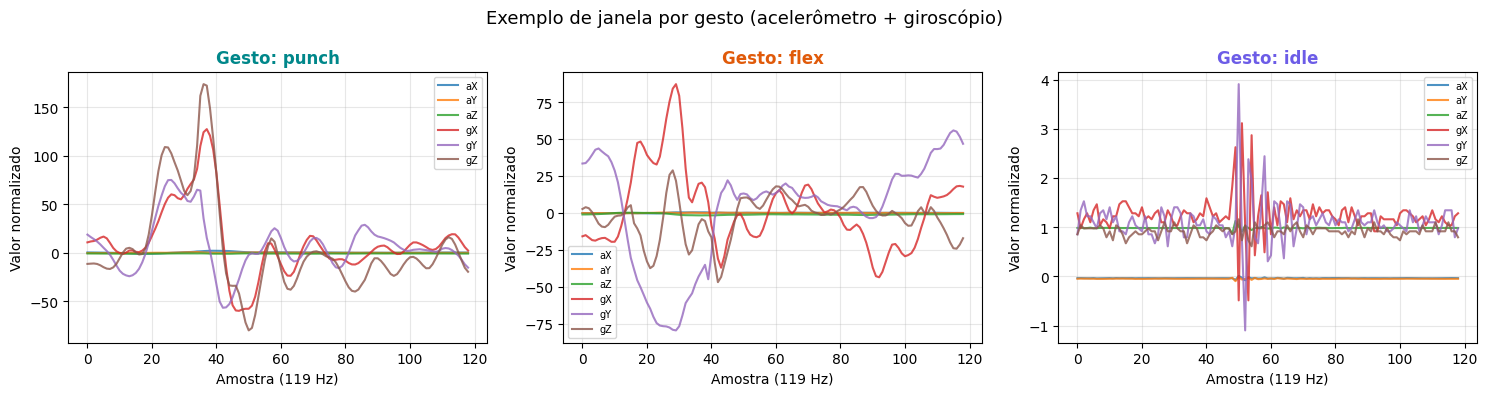

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#00878a', '#e05a0a', '#6c5ce7']
labels_ax = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']

for idx, (cls, color) in enumerate(zip(CLASSES, colors)):
    sample = X[y == idx][0]  # primeira amostra de cada classe
    for fi in range(NUM_FEATURES):
        axes[idx].plot(sample[:, fi], label=labels_ax[fi], alpha=0.8)
    axes[idx].set_title(f'Gesto: {cls}', fontweight='bold', color=color)
    axes[idx].set_xlabel('Amostra (119 Hz)')
    axes[idx].set_ylabel('Valor normalizado')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Exemplo de janela por gesto (acelerômetro + giroscópio)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pré-processamento

In [15]:
# 5.1 Normalização global (mean=0, std=1) por feature
X_flat = X.reshape(-1, NUM_FEATURES)
mean = X_flat.mean(axis=0)
std  = X_flat.std(axis=0) + 1e-8

X_norm = (X - mean) / std

print('Estatísticas por feature (após normalização):')
df_stats = pd.DataFrame({'feature': labels_ax,
                         'média_original': mean,
                         'std_original':   std})
print(df_stats.to_string(index=False))

# Salvar normalização para usar no Arduino
os.makedirs('../outputs', exist_ok=True)
np.save('../outputs/norm_mean.npy', mean)
np.save('../outputs/norm_std.npy',  std)
print('\nParâmetros de normalização salvos ✓')

Estatísticas por feature (após normalização):
feature  média_original  std_original
     aX        0.075095      0.439748
     aY       -0.179645      0.337743
     aZ       -0.217099      0.905544
     gX        2.627902     26.584227
     gY       -0.093792     31.200781
     gZ        2.936089     35.281960

Parâmetros de normalização salvos ✓


In [16]:
# 5.2 Flatten: (N, 119, 6) → (N, 714)
X_in = X_norm.reshape(len(X_norm), -1).astype(np.float32)

# 5.3 One-hot encode
y_oh = tf.keras.utils.to_categorical(y, NUM_CLASSES).astype(np.float32)

# 5.4 Split treino / validação / teste
X_train, X_temp, y_train, y_temp = train_test_split(X_in, y_oh, test_size=0.3,
                                                     stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5,
                                                     random_state=SEED)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')
print(f'Dimensão de entrada por amostra: {X_train.shape[1]}')

Treino:    21 amostras
Validação: 4 amostras
Teste:     5 amostras
Dimensão de entrada por amostra: 714


## 6. Arquitetura do modelo

Usamos uma rede **Dense** compacta propositalmente — caberá em ~50 KB de Flash no Arduino.

```
Input (714)
  └─ Dense 64, ReLU + BatchNorm + Dropout 0.3
       └─ Dense 32, ReLU + BatchNorm + Dropout 0.2
            └─ Dense 16, ReLU
                 └─ Dense 3, Softmax  ← saída (classe)
```

In [17]:
from tensorflow.keras import layers, models, optimizers, callbacks

def build_model(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,), name='input')
    x = layers.Dense(64, activation='relu', name='dense1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(0.3, name='drop1')(x)
    x = layers.Dense(32, activation='relu', name='dense2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.2, name='drop2')(x)
    x = layers.Dense(16, activation='relu', name='dense3')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return models.Model(inp, out, name='gesture_classifier')


model = build_model(X_train.shape[1], NUM_CLASSES)
model.summary()

# Número de parâmetros
params = model.count_params()
print(f'\nTotal de parâmetros: {params:,}')
print(f'Tamanho estimado (float32): {params * 4 / 1024:.1f} KB')

E0000 00:00:1778259524.011460   21195 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "gesture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 714)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        45,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,803 (190.64 KB)

 Trainable params: 48,611 (189.89 KB)

 Non-trainable params: 192 (768.00 B)


Total de parâmetros: 48,803
Tamanho estimado (float32): 190.6 KB


## 7. Treinamento

In [18]:
model.compile(
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True,
                            verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                                min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('../outputs/best_model.keras',
                               save_best_only=True, monitor='val_accuracy', verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.2857 - loss: 1.2718 - val_accuracy: 0.5000 - val_loss: 1.0562 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6667 - loss: 0.8284 - val_accuracy: 0.5000 - val_loss: 0.9804 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7143 - loss: 0.7326 - val_accuracy: 0.5000 - val_loss: 0.9190 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8095 - loss: 0.5924 - val_accuracy: 0.7500 - val_loss: 0.8424 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8095 - loss: 0.5513 - val_accuracy: 0.7500 - val_loss: 0.7748 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7619 - loss: 0.5275 - val_accuracy: 0.7500 - val_loss: 0.7259 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8095 - loss: 0.4832 - val_accuracy:

## 8. Curvas de aprendizado

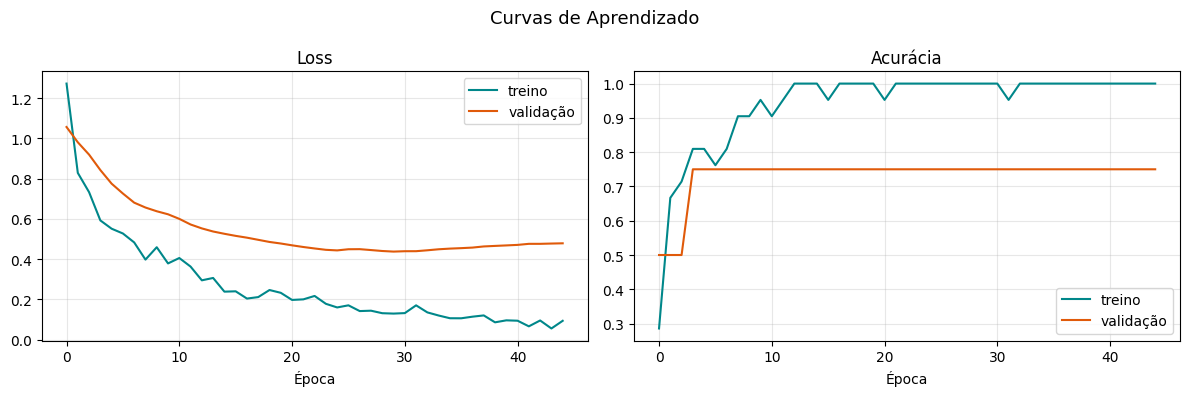

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='treino',    color='#00878a')
ax1.plot(history.history['val_loss'], label='validação', color='#e05a0a')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='treino',    color='#00878a')
ax2.plot(history.history['val_accuracy'], label='validação', color='#e05a0a')
ax2.set_title('Acurácia')
ax2.set_xlabel('Época')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizado', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/curvas_aprendizado.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Avaliação no conjunto de teste

Loss teste:     0.1560
Acurácia teste: 100.00%

              precision    recall  f1-score   support

       punch       1.00      1.00      1.00         2
        flex       1.00      1.00      1.00         2
        idle       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



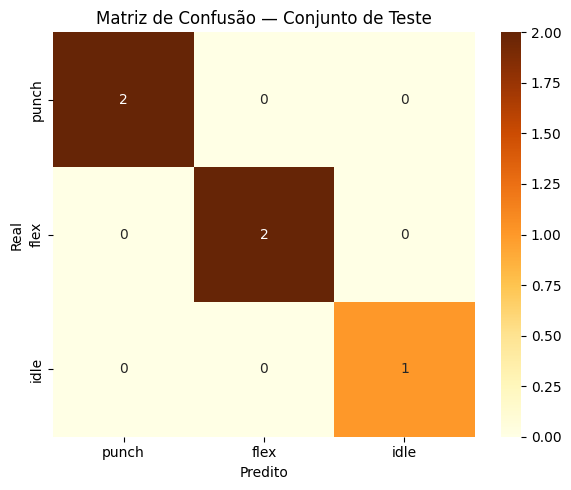

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss teste:     {loss_test:.4f}')
print(f'Acurácia teste: {acc_test*100:.2f}%\n')

y_pred = model.predict(X_test, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(y_test, axis=1)

print(classification_report(y_true_cls, y_pred_cls, target_names=CLASSES))

# Matriz de confusão
cm = confusion_matrix(y_true_cls, y_pred_cls)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Conjunto de Teste')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Salvar modelo

In [ ]:
# Formato SavedModel (para converter com TFLite Converter)
model.export('../outputs/saved_model')
print('SavedModel salvo em ../outputs/saved_model/ ✓')

# Formato HDF5 (legado, compatível com TF 2.x)
model.save('../outputs/gesture_model.h5')
print('HDF5 salvo em     ../outputs/gesture_model.h5 ✓')

INFO:tensorflow:Assets written to: ../outputs/saved_model/assets


INFO:tensorflow:Assets written to: ../outputs/saved_model/assets


Saved artifact at '../outputs/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127434003019936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003014656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003728864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003726752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003727104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003728160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003732560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003733264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003736256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003738192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127434003735376: Tensor

SavedModel salvo em ../outputs/saved_model/ ✓
HDF5 salvo em     ../outputs/gesture_model.h5 ✓

✅ Próximo passo: abrir o notebook 02_conversao_tflite.ipynb
